# Figure 7: Batch Mediation And FA Sensitivity Panels

- **Panel A:** Batch mediation of the age-IQM relationship (linear and GAM variants).
- **Panel B:** Combined winner-take-all plus GAM mediation paired bars.
- **Panel C:** FA age effect with vs without quality covariate, plus a separate 1-mediation bar panel.

- **Panel D:** GE-only 4-column x 3-row grid (row1 dual-axis bars, row2 GAM plots, row3 GE FA before/after QC).


## Shared Setup

Libraries, config, plot style, figure directory, theme, and IQM/metric helpers.


In [15]:
# --- Libraries ---
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(readr)
  library(stringr)
  library(purrr)
  library(scales)
  library(patchwork)
  library(grid)
})
if (requireNamespace("ggpattern", quietly = TRUE)) library(ggpattern)

# --- Config and project paths ---
find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)
plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
plot_style$axis_line_width <- 0.35
plot_style$axis_tick_width <- 0.35
figure7_dir <- fs::path(project_root, "figures", "Figure7")
figure7_panels_dir <- fs::path(figure7_dir, "panels")
fs::dir_create(figure7_panels_dir, recurse = TRUE)
font_family_use <- get_export_font_family()

# --- Panel theme helper (uses plot_style + font) ---
make_panel_theme <- function(legend_position = "none") {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = 6,
    axis_text_pt = 5,
    plot_title_pt = 7,
    legend_title_pt = 5,
    legend_text_pt = 5,
    base_size_pt = 10
  ) +
    theme(text = element_text(family = font_family_use))
}
# save_plot_outputs from plot_style.R (panel out_dir = figure7_panels_dir)

# --- Microstructural metrics and display labels ---
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")
metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)
metric_order <- c("MKT", "ICVF", "RTOP", "FA", "MD")

# --- IQM (image quality metric) list and family/display helpers ---
iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation", "qc_prediction"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)
classify_family <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier")
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("Neighbor Corr")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier Score")
  if (iqm == "t1_dice_distance") return("dMRI-T1w Coregistration")
  if (iqm %in% c("mean_fd", "max_fd", "max_rotation", "max_translation", "max_rel_rotation", "max_rel_translation")) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed \\(post-B1\\)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed \\(pre-B1\\)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}
family_order <- c(
  "Neighbor Corr",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration",
  "Quality Classifier"
)
family_colors <- c(
  "Neighbor Corr" = "#1b9e77",
  "dMRI Contrast" = "#d95f02",
  "Coherence/Incoherence" = "#7570b3",
  "Bad Slices" = "#e7298a",
  "Motion" = "#66a61e",
  "tSNR/CNR" = "#e6ab02",
  "Coregistration" = "#a6761d",
  "Quality Classifier" = "black"
)
# Build lookup: iqm -> pretty label and family for bar chart
iqm_dict <- tibble(iqm = iqm_metrics) %>%
  mutate(
    iqm_label = map_chr(iqm, format_iqm_label),
    family = factor(map_chr(iqm, classify_family), levels = family_order)
  )




## GE 4-column by 3-row grid

Columns (left to right):
- Preprocessed dMRI Contrast (`t1post_dwi_contrast`)
- Mean Framewise Displacement (`mean_fd`)
- Quality Classifier Score (`qc_prediction`)
- Preprocessed NDC (`t1post_neighbor_corr`)

Rows:
- Row 1: paired bars per IQM for GAM age `R^2` (decimal, left y-axis) and `% mediated by batch_device_software` (right y-axis).
- Row 2: GE-only GAM scatter panels (age vs IQM), points colored by GE software version, with black GAM fit and 95% CI.
- Row 3: GE FA age effects before vs after adding the IQM covariate.



Warning message in geom_hline(data = row2_median_df, aes(yintercept = median_iqm, :
"Ignoring unknown parameters: `inherit.aes`"
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/Figure7_row1_ge_dual_axis_bars_4iqm.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/Figure7_row1_ge_dual_axis_bars_4iqm.png

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/Figure7_row2_ge_gam_scatter_4iqm.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/Figure7_row2_ge_gam_scatter_4iqm.png

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/Figure7_row3_ge_fa_before_after_qc_4iqm.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/panels/

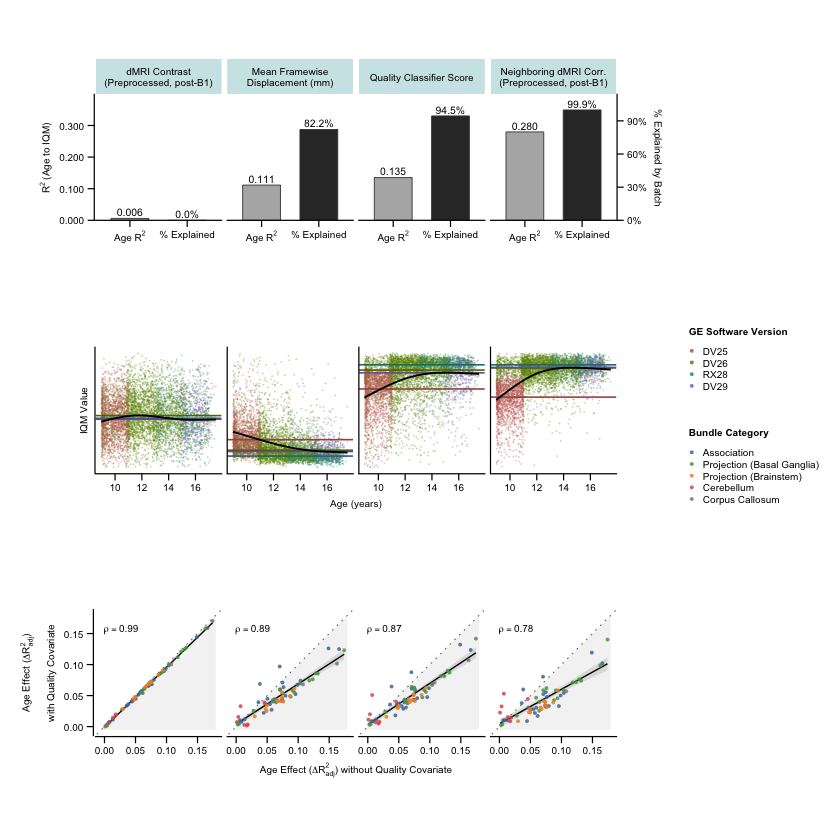

In [ ]:
# --- GE 4x3 grid (aligned facets): row1 bars, row2 GAM, row3 GE FA before/after QC ---
if (!requireNamespace("mgcv", quietly = TRUE)) {
  message("Skip GE 4x3 grid: package 'mgcv' not installed.")
} else {
  harm_path_ge <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
  age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
  iqms_ge_grid <- c("t1post_dwi_contrast", "mean_fd", "qc_prediction", "t1post_neighbor_corr")
  iqm_titles <- c(
    "t1post_dwi_contrast" = "dMRI Contrast\n(Preprocessed, post-B1)",
    "qc_prediction" = "Quality Classifier Score",
    "mean_fd" = "Mean Framewise\nDisplacement (mm)",
    "t1post_neighbor_corr" = "Neighboring dMRI Corr.\n(Preprocessed, post-B1)"
  )
  if (!file.exists(harm_path_ge)) {
    message("Skip GE 4x3 grid: harmonized parquet not found: ", harm_path_ge)
  } else if (!file.exists(age_effect_file)) {
    message("Skip GE 4x3 grid: age-effects file not found: ", age_effect_file)
  } else {
    harm_schema <- arrow::open_dataset(harm_path_ge, format = "parquet")$schema$names
    need_harm <- c("age", "scanner_manufacturer", "batch_device_software", iqms_ge_grid)
    miss_harm <- setdiff(need_harm, harm_schema)
    if (length(miss_harm) > 0) {
      message("Skip GE 4x3 grid: missing columns in harmonized parquet: ", paste(miss_harm, collapse = ", "))
    } else {
      clamp01 <- function(x) pmin(pmax(x, 0), 1)
      darken <- function(col, amount = 0.25) {
        m <- col2rgb(col, alpha = FALSE)
        rgb((1 - amount) * m[1, ] / 255, (1 - amount) * m[2, ] / 255, (1 - amount) * m[3, ] / 255)
      }
      lighten <- function(col, amount = 0.35) {
        m <- col2rgb(col, alpha = FALSE)
        rgb(
          (1 - amount) * m[1, ] / 255 + amount,
          (1 - amount) * m[2, ] / 255 + amount,
          (1 - amount) * m[3, ] / 255 + amount
        )
      }
      extract_ge_software <- function(x) {
        x_chr <- as.character(x)
        out_exact <- stringr::str_match(x_chr, "GE_([A-Za-z0-9]+)$")[, 2]
        out_any <- stringr::str_match(x_chr, ".*GE_([A-Za-z0-9]+).*")[, 2]
        dplyr::coalesce(out_exact, out_any, "Unknown")
      }
      family_colors_ge <- c(family_colors, "Other" = "gray50")
      iqm_label_levels <- unname(iqm_titles[iqms_ge_grid])
      iqm_meta <- tibble(iqm = iqms_ge_grid) %>%
        mutate(
          iqm_label = factor(unname(iqm_titles[iqm]), levels = iqm_label_levels),
          family = purrr::map_chr(iqm, classify_family),
          base_color = unname(family_colors_ge[family]),
          base_color = if_else(is.na(base_color), "gray60", base_color),
          color_r2 = lighten(base_color, amount = 0.35),
          color_med = darken(base_color, amount = 0.25)
        )
      
      # Row-2 GE GAM panel y-limits (per IQM facet)
      gam_limits <- tibble(
        iqm = iqms_ge_grid,
        ymin = c(1.5, NA_real_, 0.25, 0.85),
        ymax = c(2.25, 3.0, NA_real_, 0.95)
      )
base_strip_theme <- theme(
        strip.background = element_rect(fill = "#CFE6E6", color = NA),
        strip.text = element_text(size = 6, color = "black", face = "plain")
      )
      # ---------- GE harmonized data ----------
      df_ge <- arrow::read_parquet(harm_path_ge, col_select = tidyselect::all_of(need_harm)) %>%
        as_tibble() %>%
        mutate(
          age = as.numeric(age),
          scanner_manufacturer = as.character(scanner_manufacturer),
          batch_device_software = as.character(batch_device_software)
        ) %>%
        filter(scanner_manufacturer == "GE", !is.na(age), !is.na(batch_device_software))
      if (nrow(df_ge) < 50) {
        message("Skip GE 4x3 grid: fewer than 50 GE rows with age + batch_device_software.")
      } else {
        # ---------- Row 1: dual-axis bars ----------
        ge_gam_stats <- purrr::map_dfr(iqms_ge_grid, function(iqm_col) {
          df_iqm <- df_ge %>%
            transmute(
              age = age,
              batch_device_software = as.factor(batch_device_software),
              iqm_val = suppressWarnings(as.numeric(.data[[iqm_col]]))
            ) %>%
            filter(complete.cases(.))
          if (nrow(df_iqm) < 50) {
            return(tibble(iqm = iqm_col, n = nrow(df_iqm), r2_age_only = NA_real_, prop_mediated_gam = NA_real_))
          }
          m_age_only <- tryCatch(
            mgcv::gam(iqm_val ~ s(age, k = 4), data = df_iqm, method = "REML"),
            error = function(e) NULL
          )
          m_batch_only <- tryCatch(
            mgcv::gam(iqm_val ~ batch_device_software, data = df_iqm, method = "REML"),
            error = function(e) NULL
          )
          m_full <- tryCatch(
            mgcv::gam(iqm_val ~ s(age, k = 4) + batch_device_software, data = df_iqm, method = "REML"),
            error = function(e) NULL
          )
          if (is.null(m_age_only) || is.null(m_batch_only) || is.null(m_full)) {
            return(tibble(iqm = iqm_col, n = nrow(df_iqm), r2_age_only = NA_real_, prop_mediated_gam = NA_real_))
          }
          r2_total <- max(0, summary(m_age_only)$r.sq)
          r2_batch <- max(0, summary(m_batch_only)$r.sq)
          r2_full <- max(0, summary(m_full)$r.sq)
          r2_age_given_batch <- max(0, r2_full - r2_batch)
          prop_mediated <- if (r2_total < 1e-10) {
            NA_real_
          } else {
            clamp01(1 - (r2_age_given_batch / r2_total))
          }
          tibble(iqm = iqm_col, n = nrow(df_iqm), r2_age_only = r2_total, prop_mediated_gam = prop_mediated)
        }) %>%
          left_join(iqm_meta, by = "iqm")
        r2_axis_max <- max(0.03, max(ge_gam_stats$r2_age_only, na.rm = TRUE) * 1.25)
        if (!is.finite(r2_axis_max)) r2_axis_max <- 0.03
        pct_to_r2 <- r2_axis_max / 100
        row1_long <- ge_gam_stats %>%
          transmute(
            iqm,
            iqm_label,
            color_r2,
            color_med,
            r2_age_only,
            pct_mediated = prop_mediated_gam * 100
          ) %>%
          pivot_longer(cols = c(r2_age_only, pct_mediated), names_to = "measure_code", values_to = "value") %>%
          filter(is.finite(value)) %>%
          mutate(
            measure = recode(measure_code, r2_age_only = "Age R2", pct_mediated = "% Explained"),
            measure = factor(measure, levels = c("Age R2", "% Explained")),
            fill_key = paste0(iqm, if_else(measure == "Age R2", "_r2", "_med")),
            value_plot = if_else(measure == "Age R2", value, value * pct_to_r2),
            label = if_else(measure == "Age R2", sprintf("%.3f", value), sprintf("%.1f%%", value))
          )
        fill_vals <- c(
          setNames(rep("grey70", nrow(iqm_meta)), paste0(iqm_meta$iqm, "_r2")),
          setNames(rep("grey20", nrow(iqm_meta)), paste0(iqm_meta$iqm, "_med"))
        )
        p_row1 <- ggplot(row1_long, aes(x = measure, y = value_plot, fill = fill_key)) +
          geom_col(width = 0.66, color = "grey25", linewidth = 0.25) +
          geom_text(aes(label = label), vjust = -0.35, size = 2.2) +
          scale_fill_manual(values = fill_vals, drop = FALSE, guide = "none") +
          scale_x_discrete(labels = function(x) parse(text = vapply(as.character(x), function(lab) if (identical(lab, "Age R2")) "Age~R^2" else if (identical(lab, "% Explained")) "\"% Explained\"" else lab, character(1)))) +
          scale_y_continuous(
            limits = c(0, r2_axis_max),
            expand = expansion(mult = c(0, 0.14)),
            labels = scales::number_format(accuracy = 0.001),
            sec.axis = sec_axis(~ . / pct_to_r2, name = "% Explained by Batch", labels = scales::label_number(suffix = "%"))
          ) +
          labs(x = NULL, y = expression(R^2 ~ "(Age to IQM)")) +
          facet_wrap(~ iqm_label, nrow = 1) +
          make_panel_theme(legend_position = "none") +
          base_strip_theme +
          theme(
            panel.grid = element_blank(),
            panel.spacing.x = unit(1.2, "mm"),
            axis.text.x = element_text(size = 6, color = "black"),
            axis.text.y = element_text(size = 6, color = "black"),
            axis.title = element_text(size = 6),
            axis.title.y.right = element_text(size = 6),
            axis.text.y.right = element_text(size = 6, color = "black"),
            aspect.ratio = 1,
            plot.margin = margin(1, 2, 1, 2)
          )
        # ---------- Row 2: GE GAM scatter ----------
        df_ge_long <- df_ge %>%
          transmute(
            age = age,
            software_version = extract_ge_software(batch_device_software),
            across(all_of(iqms_ge_grid), ~ suppressWarnings(as.numeric(.x)))
          ) %>%
          pivot_longer(cols = all_of(iqms_ge_grid), names_to = "iqm", values_to = "iqm_val") %>%
          filter(!is.na(age), !is.na(iqm_val)) %>%
          left_join(iqm_meta %>% select(iqm, iqm_label), by = "iqm") %>%
          left_join(gam_limits, by = "iqm") %>%
          mutate(
            iqm_label = factor(iqm_label, levels = iqm_label_levels),
            in_panel_limits = (is.na(ymin) | iqm_val >= ymin) & (is.na(ymax) | iqm_val <= ymax)
          )
        software_preferred <- c("DV25", "DV26", "RX28", "DV29", "D29")
        software_present <- df_ge_long %>%
          distinct(software_version) %>%
          pull(software_version) %>%
          as.character()
        software_levels <- c(
          intersect(software_preferred, software_present),
          setdiff(software_present, software_preferred)
        )
        df_ge_long <- df_ge_long %>%
          mutate(software_version = factor(as.character(software_version), levels = software_levels))
        software_palette <- setNames(scales::hue_pal(h = c(15, 375), c = 70, l = 55)(length(software_levels)), software_levels)
        software_median_palette <- setNames(
          vapply(software_palette, darken, FUN.VALUE = character(1), amount = 0.18),
          names(software_palette)
        )
        pred_df <- purrr::map_dfr(iqms_ge_grid, function(iqm_col) {
          df_iqm <- df_ge_long %>% filter(iqm == iqm_col)
          if (nrow(df_iqm) < 50) return(tibble())
          m_iqm <- tryCatch(
            mgcv::gam(iqm_val ~ s(age, k = 4), data = df_iqm, method = "REML"),
            error = function(e) NULL
          )
          if (is.null(m_iqm)) return(tibble())
          age_grid <- seq(min(df_iqm$age, na.rm = TRUE), max(df_iqm$age, na.rm = TRUE), length.out = 250)
          pred <- predict(m_iqm, newdata = tibble(age = age_grid), se.fit = TRUE)
          tibble(
            iqm = iqm_col,
            age = age_grid,
            fit = as.numeric(pred$fit),
            se = as.numeric(pred$se.fit),
            lo = fit - 1.96 * se,
            hi = fit + 1.96 * se
          ) %>%
            left_join(iqm_meta %>% select(iqm, iqm_label), by = "iqm") %>%
            left_join(gam_limits, by = "iqm") %>%
            mutate(
              iqm_label = factor(iqm_label, levels = iqm_label_levels),
              fit = pmax(fit, dplyr::coalesce(ymin, -Inf)),
              fit = pmin(fit, dplyr::coalesce(ymax, Inf)),
              lo = pmax(lo, dplyr::coalesce(ymin, -Inf)),
              lo = pmin(lo, dplyr::coalesce(ymax, Inf)),
              hi = pmax(hi, dplyr::coalesce(ymin, -Inf)),
              hi = pmin(hi, dplyr::coalesce(ymax, Inf))
            )
        })
        row2_limits_df <- gam_limits %>%
          filter(!is.na(ymin) | !is.na(ymax)) %>%
          left_join(iqm_meta %>% select(iqm, iqm_label), by = "iqm") %>%
          mutate(age = mean(df_ge_long$age, na.rm = TRUE)) %>%
          pivot_longer(cols = c(ymin, ymax), names_to = "limit_type", values_to = "iqm_val") %>%
          filter(!is.na(iqm_val)) %>%
          select(iqm_label, age, iqm_val)
        df_ge_long_plot <- df_ge_long %>%
          filter(in_panel_limits)
        row2_median_df <- df_ge_long_plot %>%
          group_by(iqm_label, software_version) %>%
          summarise(
            median_iqm = median(iqm_val, na.rm = TRUE),
            .groups = "drop"
          ) %>%
          mutate(median_color = unname(software_median_palette[as.character(software_version)]))
        p_row2 <- ggplot(df_ge_long_plot, aes(x = age, y = iqm_val, color = software_version)) +
          geom_point(size = 0.50, alpha = 0.35, stroke = 0) +
          geom_blank(data = row2_limits_df, aes(x = age, y = iqm_val), inherit.aes = FALSE) +
          geom_ribbon(
            data = pred_df,
            aes(x = age, ymin = lo, ymax = hi),
            inherit.aes = FALSE,
            fill = "black",
            alpha = 0.16
          ) +
          geom_hline(
            data = row2_median_df,
            aes(yintercept = median_iqm, color = I(median_color)),
            inherit.aes = FALSE,
            linewidth = 0.45,
            show.legend = FALSE
          ) +
          geom_line(
            data = pred_df,
            aes(x = age, y = fit),
            inherit.aes = FALSE,
            color = "black",
            linewidth = 0.52
          ) +
          scale_color_manual(values = software_palette, drop = FALSE, name = "GE Software Version") +
          guides(color = guide_legend(override.aes = list(size = 1.1, alpha = 0.85))) +
          labs(x = "Age (years)", y = "IQM Value") +
          facet_wrap(~ iqm_label, nrow = 1, scales = "free_y") +
          make_panel_theme(legend_position = "right") +
          theme(
            panel.grid = element_blank(),
            panel.spacing.x = unit(1.2, "mm"),
            strip.text = element_blank(),
            strip.background = element_blank(),
            axis.text.x = element_text(size = 6, color = "black"),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.title = element_text(size = 6),
            legend.text = element_text(size = 6),
            legend.title = element_text(size = 6),
            legend.key.size = unit(3.5, "pt"),
            aspect.ratio = 1,
            plot.margin = margin(1, 2, 1, 2)
          )
        # ---------- Row 3: GE age effects before vs after QC ----------
        df_age_all <- readRDS(age_effect_file)
        need_age <- c("bundle", "bundle_category", "metric", "qc_metric", "source", "output_type", "scanner_manufacturer", "age_effect_size")
        if (!all(need_age %in% names(df_age_all))) {
          message("Skip GE row 3: age-effects RDS missing required columns.")
        } else {
          # Temporary metric swap for row 3 comparisons.
          row3_metric <- "GQI_fa"
          df_age_ge <- df_age_all %>%
            filter(
              metric == row3_metric,
              source == "harmonized",
              output_type == "vendorwise",
              scanner_manufacturer == "GE",
              qc_metric %in% c("no_quality", iqms_ge_grid),
              !is.na(bundle),
              !is.na(bundle_category),
              !is.na(age_effect_size)
            ) %>%
            mutate(
              bundle_category_pretty = recode(bundle_category, !!!category_label_map),
              bundle_category_pretty = factor(bundle_category_pretty, levels = category_order_pretty)
            )
          no_qc <- df_age_ge %>%
            filter(qc_metric == "no_quality") %>%
            select(bundle, bundle_category_pretty, age_no_qc = age_effect_size)
          with_qc <- df_age_ge %>%
            filter(qc_metric %in% iqms_ge_grid) %>%
            select(bundle, iqm = qc_metric, age_with_qc = age_effect_size)
          row3_df <- no_qc %>%
            inner_join(with_qc, by = "bundle") %>%
            filter(iqm %in% iqms_ge_grid) %>%
            left_join(iqm_meta %>% select(iqm, iqm_label), by = "iqm") %>%
            mutate(iqm_label = factor(iqm_label, levels = iqm_label_levels))
          if (nrow(row3_df) == 0) {
            message("Skip GE row 3: no matching GE rows for before/after QC.")
          } else {
            xy_lim <- range(c(row3_df$age_no_qc, row3_df$age_with_qc), na.rm = TRUE)
            if (!all(is.finite(xy_lim))) xy_lim <- c(0, 0.1)
            pad <- diff(xy_lim) * 0.03
            if (!is.finite(pad) || pad <= 0) pad <- 0.01
            xy_lim <- xy_lim + c(-pad, pad)
            shade_x <- seq(xy_lim[1], xy_lim[2], length.out = 200)
            shade_df <- tibble(
              x = shade_x,
              y_low = xy_lim[1],
              y_high = pmin(shade_x, xy_lim[2])
            )
            rho_df <- row3_df %>%
              group_by(iqm_label) %>%
              summarise(
                rho = suppressWarnings(cor(age_no_qc, age_with_qc, method = "spearman", use = "pairwise.complete.obs")),
                .groups = "drop"
              ) %>%
              mutate(
                rho_lab = if_else(is.finite(rho), sprintf("rho == %.2f", rho), "rho == plain(\"NA\")"),
                x_anno = xy_lim[1] + 0.02 * diff(xy_lim),
                y_anno = xy_lim[2] - 0.08 * diff(xy_lim)
              )
            p_row3 <- ggplot(row3_df, aes(x = age_no_qc, y = age_with_qc, color = bundle_category_pretty)) +
              geom_ribbon(
                data = shade_df,
                aes(x = x, ymin = y_low, ymax = y_high),
                inherit.aes = FALSE,
                fill = "grey75",
                alpha = 0.18
              ) +
              geom_abline(intercept = 0, slope = 1, linetype = "dotted", color = "grey45", linewidth = 0.3) +
              geom_smooth(
                method = "lm",
                se = TRUE,
                color = "black",
                fill = "grey45",
                alpha = 0.18,
                linewidth = 0.4,
                inherit.aes = FALSE,
                data = row3_df,
                aes(x = age_no_qc, y = age_with_qc)
              ) +
              geom_point(size = 1.1, alpha = 0.85, stroke = 0) +
              geom_text(
                data = rho_df,
                aes(x = x_anno, y = y_anno, label = rho_lab),
                inherit.aes = FALSE,
                parse = TRUE,
                hjust = 0,
                vjust = 1,
                size = 2.1,
                family = font_family_use
              ) +
              scale_color_manual(values = bundle_color_pretty, drop = FALSE, name = "Bundle Category") +
              coord_cartesian(xlim = xy_lim, ylim = xy_lim) +
              labs(
                x = expression("FA Age Effect (" * Delta * R[adj]^2 * ") without Quality Covariate"),
                y = expression(atop("FA Age Effect (" * Delta * R[adj]^2 * ")", "with Quality Covariate"))
              ) +
              facet_wrap(~ iqm_label, nrow = 1) +
              make_panel_theme(legend_position = "right") +
              theme(
                panel.grid = element_blank(),
            panel.spacing.x = unit(1.2, "mm"),
                strip.text = element_blank(),
                strip.background = element_blank(),
                axis.text = element_text(size = 6, color = "black"),
                axis.title = element_text(size = 6),
                legend.text = element_text(size = 6),
                legend.title = element_text(size = 6),
                legend.key.size = unit(3.5, "pt"),
                aspect.ratio = 1,
                plot.margin = margin(1, 2, 1, 2)
              )
            # ---------- Combined aligned 4x3 grid ----------
            p_ge_4x3 <- p_row1 / p_row2 / p_row3 +
              patchwork::plot_layout(heights = c(1, 1, 1), guides = "collect") &
              theme(legend.position = "right", legend.text = element_text(size = 6), legend.title = element_text(size = 6), legend.key.size = unit(3.5, "pt"))
            grid_width_in <- 170 / 25.4
            row1_height_in <- 1.45
            row2_height_in <- 1.50
            row3_height_in <- 1.50
            grid_height_in <- row1_height_in + row2_height_in + row3_height_in
            save_plot_outputs(p_row1, "Figure7_row1_ge_dual_axis_bars_4iqm", figure7_panels_dir, grid_width_in, row1_height_in)
            save_plot_outputs(p_row2, "Figure7_row2_ge_gam_scatter_4iqm", figure7_panels_dir, grid_width_in, row2_height_in)
            save_plot_outputs(p_row3, "Figure7_row3_ge_fa_before_after_qc_4iqm", figure7_panels_dir, grid_width_in, row3_height_in)
            save_plot_outputs(p_ge_4x3, "Figure7_ge_4x3_grid", figure7_panels_dir, grid_width_in, grid_height_in)
            message("[SAVED] Figure7 GE 4x3 aligned facet grid + row panels")
            print(p_ge_4x3)
          }
        }
      }
    }
  }
}
